# GPCC Precipitation

Monthly land-surface precipitation from the Global Precipitation Climatology Centre at Deutscher
Wetterdienst, interpolated from rain gauges onto a one-degree grid and averaged here onto countries.
It is the only monthly series in this collection, and the only one reaching back to 1891.

## Provenance

These are the fields of the `FULL_DATA` and `MONITORING` declarations in
`climate_risk/data/gpcc.py`, which is what `fetch` reads. Check that file rather than this page if
the two ever disagree.

In [1]:
import dataclasses

from IPython.display import Markdown

from climate_risk.data.gpcc import FULL_DATA

declared = {"publisher": "Global Precipitation Climatology Centre, Deutscher Wetterdienst"} | dataclasses.asdict(
    FULL_DATA.sources[0]
)

rows = [f"| {field} | {value} |" for field, value in declared.items()]

Markdown("\n".join(["| Field | Value |", "|---|---|", *rows]))

| Field | Value |
|---|---|
| publisher | Global Precipitation Climatology Centre, Deutscher Wetterdienst |
| url | https://opendata.dwd.de/climate_environment/GPCC/full_data_monthly_v2022/10/full_data_monthly_v2022_1891_1900_10.nc.gz |
| filename | full_data_monthly_v2022_1891_1900_10.nc.gz |
| license | CC BY 4.0 |
| citation | Schneider, U., Hänsel, S., Finger, P., Rustemeier, E., Ziese, M. (2022): GPCC Full Data Monthly Product Version 2022 at 1.0 degrees. https://doi.org/10.5676/DWD_GPCC/FD_M_V2022_100 |
| retrieved | 2026-08-05 |

## Loading it

Two products are stitched into one frame. The gauge analysis covers 1891 to 2020, and the
near-real-time monitoring product carries on from there. Every grid cell is joined to the country
containing it, so a cold run pulls the world shapefile as well. The cache directory is your choice,
and this page uses one named `data` in the working directory.

In [2]:
import logging

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import climate_risk as cr

from climate_risk.plotting import PALETTE, configure_plot_style

configure_plot_style(add_grid=True)

# The package installs an INFO handler when nothing else has, and a cache hit logs a line.
logging.getLogger("climate_risk").setLevel(logging.WARNING)

In [3]:
cache_dir = Path("data")

precipitation = cr.load_gpcc_data(cache_dir)

## What you get

A pandas frame indexed by country and month, with millimeters of precipitation in the one column.
Which of polars and pandas a loader returns varies across this package, so it is worth checking per
loader.

In [4]:
precipitation.head()

precip
country_code time              
AFG          1891-01-01   59.35
             1891-02-01   59.28
             1891-03-01   43.48
             1891-04-01   40.20
             1891-05-01   18.22

## Coverage

`describe` answers the spread of the one column. The span and the country count live in the index,
so they are read off it separately.

In [5]:
precipitation.describe()

,precip
count,273780.00
mean,90.14
std,95.97
min,0.00
25%,21.24
50%,58.88
75%,126.37
max,1468.17


In [6]:
months = precipitation.index.get_level_values("time")

pd.DataFrame(
    {
        "countries": [precipitation.index.get_level_values("country_code").nunique()],
        "first month": [f"{months.min():%Y-%m}"],
        "last month": [f"{months.max():%Y-%m}"],
    }
)

,countries,first month,last month
0,169,1891-01,2025-12


## A plot

The monthly climatology for Laos, averaged across the whole record. Monthly resolution is what
distinguishes this source, and a monsoon country is where that resolution shows: almost all of the
year's rain arrives in the wet season.

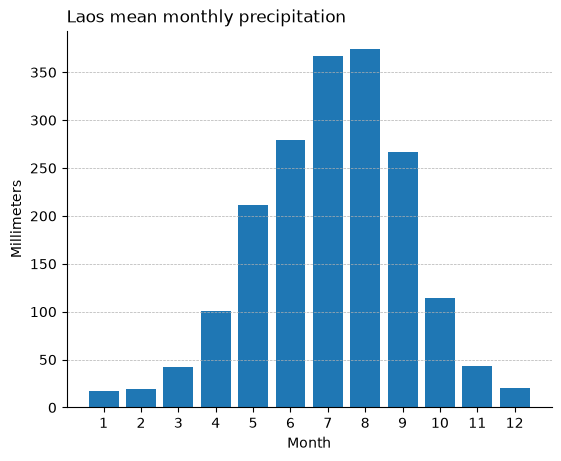

In [7]:
laos = precipitation.xs("LAO", level="country_code")
climatology = laos.groupby(laos.index.month)["precip"].mean()

figure, axis = plt.subplots(figsize=(5.5, 4.5))
axis.bar(climatology.index, climatology, color=PALETTE["primary"])
axis.set_title("Laos mean monthly precipitation", loc="left")
axis.set_xlabel("Month")
axis.set_ylabel("Millimeters")
axis.set_xticks(range(1, 13))

plt.show()

## Gotchas

*It is monthly, and everything else here is annual.* Joining this frame onto the country-year panel
means summing to annual totals first. Summing a partial year reads as a drought.

*Two products are stitched, and they are not the same instrument.* The gauge analysis to 2020 is
built from far more stations than the near-real-time monitoring product that follows it. A
discontinuity at the 2020 boundary is a change of station network, not of climate.

*The index level is `country_code`, and HadCRUT5 calls the same thing `ISO`.* Joining the two means
renaming one. Nothing enforces the convention across loaders.

*`products` is part of the cache key.* `coverage_of` turns the products you pass into the span in
the cache filename, so loading a subset builds a second entry rather than reusing the first.

*Monitoring years are whole calendar years only.* `MONITORING_END` is a hardcoded 2025, so the
series stops at a year boundary rather than at the last published month. Extending the record means
editing that constant.

*DWD writes its dates in a unit string CF does not define.* The monitoring files carry
`day as %Y%m%d.%f`, so xarray hands the time axis back undecoded and the loader parses it itself.